In [61]:
import bacco
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("/cosmos_storage/home/fgmaion/MTNG-resims/src")
import utils

In [62]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [63]:
## Load the Zooms
sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

name_list = ['LH_{:d}'.format(i) for i in range(2)] + ['fiducial']

snap = 264
zoom = {}

loaded = []
for i in range(len(name_list)):
    if i<2:
        base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/LH_{:d}/hydro_output/".format(i)
    else:
        base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/"
    zoom[name_list[i]] = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(snap,snap), sim_format='TNG500', fixedPk=True, use_orphans=False,\
                            tau=tau, ns=ns, sigma8=sigma8, dm_file="snapdir_{:03d}/snapshot_{:03d}".format(snap,snap), use_ids=True, numpart=4320)

# Load the Halo Selection
with open("/cosmos_storage/simulations/TNG_Family/MN5_resims/resims_info/hydro_halo_sel_1pmbin.txt") as f:
    final_sel = []

    for line in f.readlines():
        final_sel.append(int(line.split()[0]))

final_sel = np.array(final_sel)

# Perform the cross-match with MTNG halos
xmatch = {}

for i in range(len(name_list)):
    xmatch[name_list[i]] = utils.cross_match(zoom[name_list[i]], snap=264, name=name_list[i])

# Load MTNG and get the fraction of halos to do the upweighting
mtng = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/TNG_Family/MTNG/", snap=264)

m200b = np.log10(1e10 * mtng.fof['halo_m200b'])

mbins = np.concatenate(
    (np.arange(11, 11.5, 0.0025),
    np.arange(11.5, 12.5, 0.005),
    np.arange(12.5, 13.5, 0.025),
    np.arange(13.5, 15.01, 0.125))
)

h_frac = np.zeros(len(final_sel))
for m in range(len(mbins)-1):
    h_frac[m] = np.where(( m200b[final_sel]>=mbins[m]) & ( m200b[final_sel]<mbins[m+1]))[0].shape[0] / \
             np.where(( m200b>=mbins[m]) & ( m200b<mbins[m+1]))[0].shape[0]

zoom_split = {}
zoom_sel = {}
for i in range(len(name_list)):
    zoom_split[name_list[i]] = utils.split_halos(zoom[name_list[i]])

    zoom_sel[name_list[i]] = {}

    zoom_sel[name_list[i]]['sel'] = xmatch[name_list[i]]['ind'][:,np.newaxis,np.newaxis]
    zoom_sel[name_list[i]]['h_frac'] = h_frac[np.newaxis, :]

2026-02-27 17:50:54,065 bacco.sims : Initialising simulation Default
2026-02-27 17:50:54,068 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/snapdir_264/snapshot_264
2026-02-27 17:50:54,100 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/snapdir_264/snapshot_264


2026-02-27 17:50:54,717 bacco.sims : ...done in 0.0842 s
2026-02-27 17:50:54,718 bacco.sims : Initialising simulation Default
2026-02-27 17:50:54,719 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_1/hydro_output/snapdir_264/snapshot_264
2026-02-27 17:50:54,731 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_1/hydro_output/snapdir_264/snapshot_264
2026-02-27 17:50:55,181 bacco.sims : ...done in 0.0304 s
2026-02-27 17:50:55,182 bacco.sims : Initialising simulation Default
2026-02-27 17:50:55,182 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264
2026-02-27 17:50:55,203 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264
2026-02-27 17:50:55,668 bacco.sims : ...done in 0.0383 s
2026-02-27 17:50:55,727 bacco.sims : Initialising simulation Default
2026-02-27 17:50:55,728 bacco.sims : try /cosmos_storage/simulations/T

In [68]:
Nbins_fgas = 15

zoom_fgas = {}
zoom_smf = {}
bh_mf = {}

for i in range(len(name_list)):
    zoom_fgas[name_list[i]] = zoom_split[name_list[i]].halo_gas_frac_v2(sel_mask=zoom_sel[name_list[i]], nbins=Nbins_fgas, draws=1)    
    zoom_smf[name_list[i]] = zoom_split[name_list[i]].halo_smf_draws(sel_mask=zoom_sel[name_list[i]], nbins=Nbins_smf, draws=1, m_30kpc=True)
    bh_mf[name_list[i]] = zoom_split[name_list[i]].bh_mf(sel_mask=zoom_sel[name_list[i]], nbins=20)

2026-02-27 18:03:46,577 bacco.sims : Reading 142791 items for halo_firstsub
2026-02-27 18:03:46,629 bacco.sims : Reading 142791 items for GroupNsubs
2026-02-27 18:03:46,644 bacco.sims : Reading 76572 items for Subhalo/SubhaloOffset
2026-02-27 18:03:46,888 bacco.sims : Reading 76572 items for SubhaloLenType
2026-02-27 18:03:46,975 bacco.sims : Read data for 915494/6504089 particles...


/cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/snapdir_264/snapshot_264.0.hdf5


2026-02-27 18:03:47,586 bacco.sims : Read data for 915494/6504089 particles...
2026-02-27 18:03:47,678 bacco.sims : Read data for 799169/6504089 particles...
2026-02-27 18:03:48,264 bacco.sims : Read data for 799169/6504089 particles...
2026-02-27 18:03:48,406 bacco.sims : Read data for 810943/6504089 particles...
2026-02-27 18:03:49,122 bacco.sims : Read data for 810943/6504089 particles...
2026-02-27 18:03:49,183 bacco.sims : Read data for 841297/6504089 particles...
2026-02-27 18:03:49,771 bacco.sims : Read data for 841297/6504089 particles...
2026-02-27 18:03:49,863 bacco.sims : Read data for 796144/6504089 particles...
2026-02-27 18:03:50,356 bacco.sims : Read data for 796144/6504089 particles...
2026-02-27 18:03:50,395 bacco.sims : Read data for 779936/6504089 particles...
2026-02-27 18:03:51,015 bacco.sims : Read data for 779936/6504089 particles...
2026-02-27 18:03:51,116 bacco.sims : Read data for 742961/6504089 particles...
2026-02-27 18:03:51,680 bacco.sims : Read data for 7

/cosmos_storage/simulations/TNG_Family/MN5_resims/LH_1/hydro_output/snapdir_264/snapshot_264.0.hdf5


2026-02-27 18:04:29,594 bacco.sims : Read data for 613330/4454721 particles...
2026-02-27 18:04:29,633 bacco.sims : Read data for 563159/4454721 particles...
2026-02-27 18:04:29,951 bacco.sims : Read data for 563159/4454721 particles...
2026-02-27 18:04:29,955 bacco.sims : Read data for 502668/4454721 particles...
2026-02-27 18:04:30,232 bacco.sims : Read data for 502668/4454721 particles...
2026-02-27 18:04:30,234 bacco.sims : Read data for 586925/4454721 particles...
2026-02-27 18:04:30,625 bacco.sims : Read data for 586925/4454721 particles...
2026-02-27 18:04:30,626 bacco.sims : Read data for 521224/4454721 particles...
2026-02-27 18:04:30,927 bacco.sims : Read data for 521224/4454721 particles...
2026-02-27 18:04:30,931 bacco.sims : Read data for 557847/4454721 particles...
2026-02-27 18:04:31,186 bacco.sims : Read data for 557847/4454721 particles...
2026-02-27 18:04:31,188 bacco.sims : Read data for 592807/4454721 particles...
2026-02-27 18:04:31,509 bacco.sims : Read data for 5

/cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264.0.hdf5


2026-02-27 18:05:01,697 bacco.sims : Read data for 796017/6141061 particles...
2026-02-27 18:05:01,746 bacco.sims : Read data for 742440/6141061 particles...
2026-02-27 18:05:02,070 bacco.sims : Read data for 742440/6141061 particles...
2026-02-27 18:05:02,074 bacco.sims : Read data for 770918/6141061 particles...
2026-02-27 18:05:02,403 bacco.sims : Read data for 770918/6141061 particles...
2026-02-27 18:05:02,455 bacco.sims : Read data for 792109/6141061 particles...
2026-02-27 18:05:02,794 bacco.sims : Read data for 792109/6141061 particles...
2026-02-27 18:05:02,841 bacco.sims : Read data for 736460/6141061 particles...
2026-02-27 18:05:03,141 bacco.sims : Read data for 736460/6141061 particles...
2026-02-27 18:05:03,192 bacco.sims : Read data for 757977/6141061 particles...
2026-02-27 18:05:03,484 bacco.sims : Read data for 757977/6141061 particles...
2026-02-27 18:05:03,513 bacco.sims : Read data for 779883/6141061 particles...
2026-02-27 18:05:03,824 bacco.sims : Read data for 7

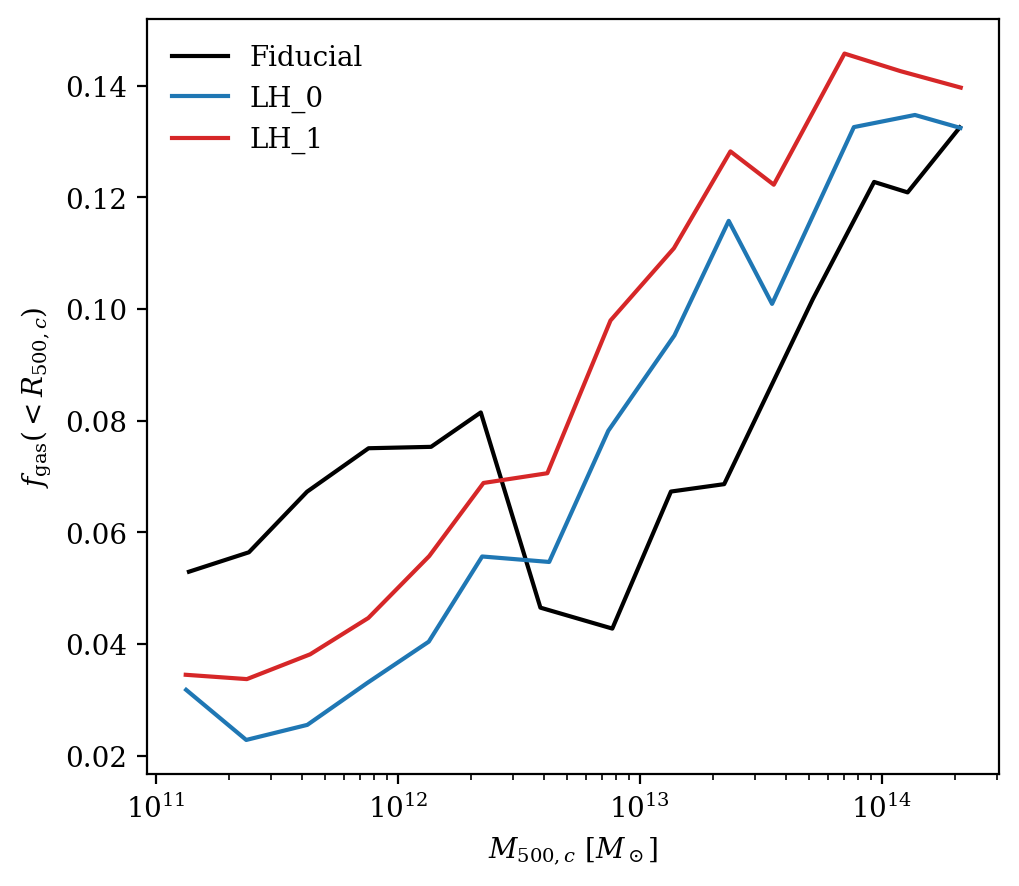

In [66]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))

ax.set_xscale("log")

ax.plot(zoom_fgas['fiducial']['m500c'][0], zoom_fgas['fiducial']['f_gas'][0], color='k')
ax.plot(zoom_fgas['LH_0']['m500c'][0], zoom_fgas['LH_0']['f_gas'][0], color='C0')
ax.plot(zoom_fgas['LH_1']['m500c'][0], zoom_fgas['LH_1']['f_gas'][0], color='C3')

ax.set_xlabel(r"$M_{500,c}$ [$M_\odot$]")
ax.set_ylabel(r"$f_\mathrm{gas}(<R_{500,c})$")

ax.legend(['Fiducial', 'LH_0', 'LH_1'], frameon=False)

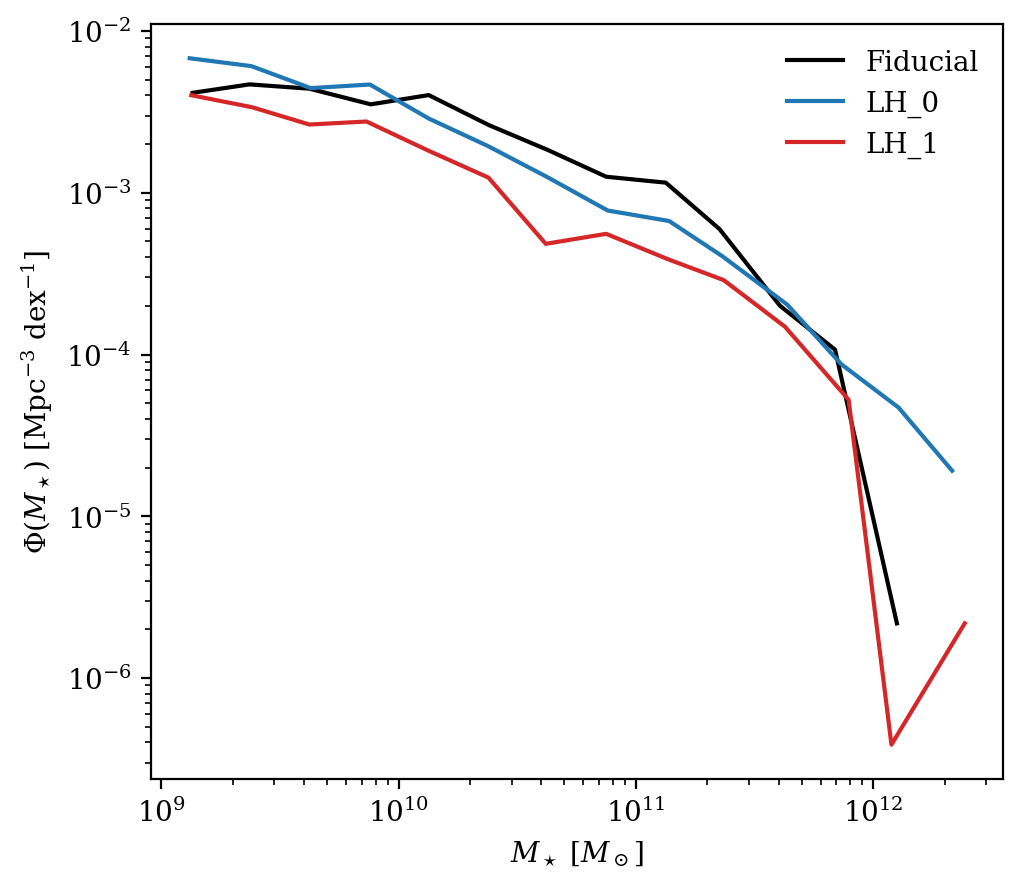

In [70]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))

ax.set_xscale("log")
ax.set_yscale("log")

ax.plot(zoom_smf['fiducial']['mstar'][0], zoom_smf['fiducial']['smf'][0], color='k')
ax.plot(zoom_smf['LH_0']['mstar'][0], zoom_smf['LH_0']['smf'][0], color='C0')
ax.plot(zoom_smf['LH_1']['mstar'][0], zoom_smf['LH_1']['smf'][0], color='C3')

ax.set_xlabel(r"$M_\star$ [$M_\odot$]")
ax.set_ylabel(r"$\Phi(M_\star)$ [Mpc$^{-3}$ dex$^{-1}$]")

ax.legend(['Fiducial', 'LH_0', 'LH_1'], frameon=False)

In [76]:
bh_mf['fiducial']['mbh']

array([1.27644719e+06, 2.35445456e+06, 3.95484116e+06, 6.73988130e+06,
       1.19147299e+07, 2.04413512e+07, 3.34210758e+07, 5.95392089e+07,
       1.03985178e+08, 1.74249858e+08, 3.12552654e+08, 5.55734768e+08,
       8.61157241e+08, 1.52935085e+09, 2.60362517e+09, 4.52340710e+09,
       9.42655181e+09, 1.40812564e+10, 2.31555963e+10])

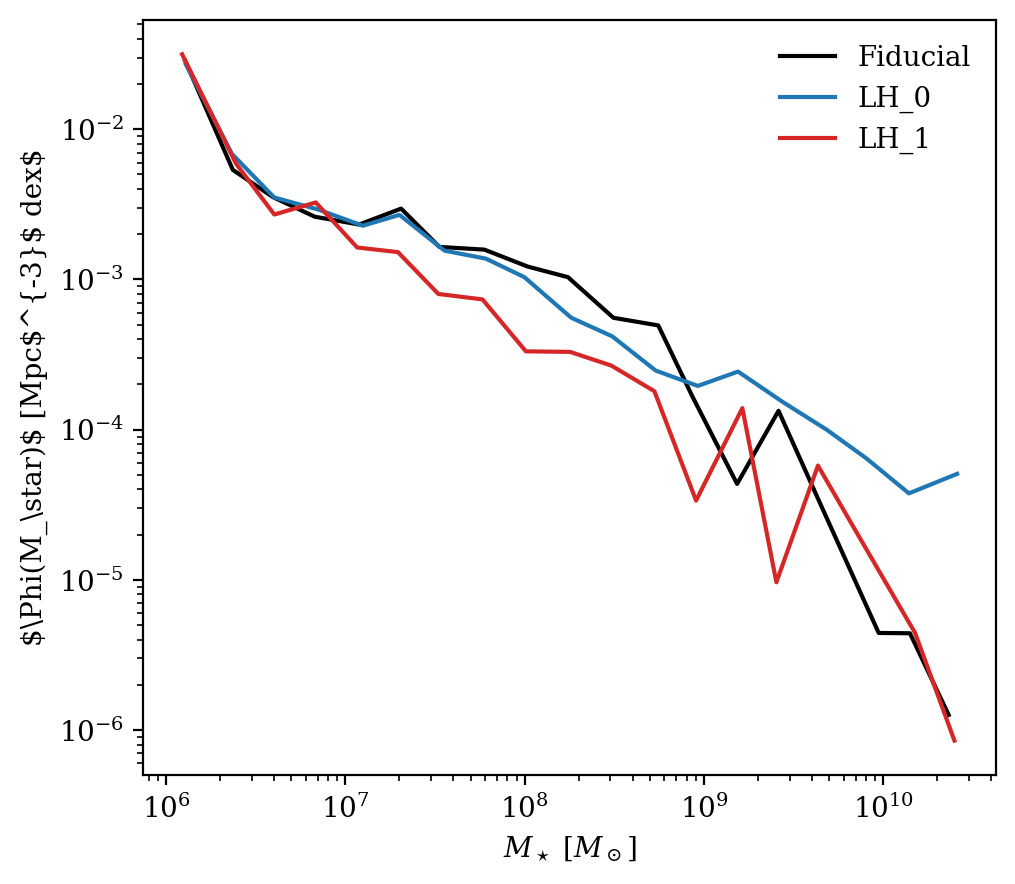

In [77]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))

ax.set_xscale("log")
ax.set_yscale("log")

ax.plot(bh_mf['fiducial']['mbh'], bh_mf['fiducial']['bhmf'], color='k')
ax.plot(bh_mf['LH_0']['mbh'], bh_mf['LH_0']['bhmf'], color='C0')
ax.plot(bh_mf['LH_1']['mbh'], bh_mf['LH_1']['bhmf'], color='C3')

ax.set_xlabel(r"$M_\star$ [$M_\odot$]")
ax.set_ylabel(r"$\Phi(M_\star)$ [Mpc$^{-3}$ dex$")

ax.legend(['Fiducial', 'LH_0', 'LH_1'], frameon=False)

In [78]:
wind_en_or      = []
wind_vel_or     = []
rho_rec_or      = []
sf_ts_or        = []
ef_kin_or       = []
ef_high_or      = []
f_re_or         = []

for i in range(31):
    if i<30:
        filename = "/cosmos_storage/simulations/TNG_Family/MN5_resims/param_LH/param_MTNG-hydro_{:d}.txt".format(i)
    else:
        filename = "/cosmos_storage/simulations/TNG_Family/MN5_resims/param_LH/param_MTNG-hydro.txt"

    with open(filename, 'r') as f:
        for line in f.readlines():
            if len(line.split())!=0:
                if line.split()[0] == 'WindEnergyIn1e51erg':
                    wind_en_or.append(float(line.split()[1]))
                if line.split()[0] == 'VariableWindVelFactor':
                    wind_vel_or.append(float(line.split()[1]))
                if line.split()[0] == 'WindFreeTravelDensFac':
                    rho_rec_or.append(float(line.split()[1]))
                if line.split()[0] == 'MaxSfrTimescale':
                    sf_ts_or.append(float(line.split()[1]))
                if line.split()[0] == 'RadioFeedbackFactor':
                    ef_kin_or.append(float(line.split()[1]))
                if line.split()[0] == 'BlackHoleFeedbackFactor':
                    ef_high_or.append(float(line.split()[1]))
                if line.split()[0] == 'RadioFeedbackReiorientationFactor':
                    f_re_or.append(float(line.split()[1]))

rho_rec_or = np.log10(rho_rec_or)
ef_kin_or = np.log10(ef_kin_or)
        
wind_en   = (np.asarray(wind_en_or) - np.mean(wind_en_or)) / np.std(wind_en_or)
wind_vel  = (np.asarray(wind_vel_or) - np.mean(wind_vel_or)) / np.std(wind_vel_or)
rho_rec   = (np.asarray(rho_rec_or) - np.mean(rho_rec_or)) / np.std(rho_rec_or)
sf_ts     = (np.asarray(sf_ts_or) - np.mean(sf_ts_or)) / np.std(sf_ts_or)
ef_kin    = (np.asarray(ef_kin_or) - np.mean(ef_kin_or)) / np.std(ef_kin_or)
ef_high   = (np.asarray(ef_high_or) - np.mean(ef_high_or)) / np.std(ef_high_or)
f_re      = (np.asarray(f_re_or) - np.mean(f_re_or)) / np.std(f_re_or)

In [86]:
print("WindEnergyIn1e51erg:               fiducial {:.2f}, LH_0 {:.2f}, LH_1 {:.2f}".format(wind_en_or[30], wind_en_or[0], wind_en_or[1]))
print("VariableWindVelFactor:             fiducial {:.2f}, LH_0 {:.2f}, LH_1 {:.2f}".format(wind_vel_or[30], wind_vel_or[0], wind_vel_or[1] ))
print("WindFreeTravelDensFac:             fiducial {:.2f}, LH_0 {:.2f}, LH_1 {:.2f}".format(rho_rec_or[30], rho_rec_or[0], rho_rec_or[1] ))
print("MaxSfrTimescale:                   fiducial {:.4f}, LH_0 {:.4f}, LH_1 {:.4f}".format(sf_ts_or[30], sf_ts_or[0], sf_ts_or[1] ))
print("RadioFeedbackFactor:               fiducial {:.4f}, LH_0 {:.4f}, LH_1 {:.4f}".format(ef_kin_or[30], ef_kin_or[0], ef_kin_or[1] ))
print("BlackHoleFeedbackFactor:           fiducial {:.2f}, LH_0 {:.2f}, LH_1 {:.2f}".format(ef_high_or[30], ef_high_or[0], ef_high_or[1] ))
print("RadioFeedbackReiorientationFactor: fiducial {:.2f}, LH_0 {:.2f}, LH_1 {:.2f}".format(f_re_or[30], f_re_or[0], f_re_or[1] ))

WindEnergyIn1e51erg:               fiducial 3.60, LH_0 3.05, LH_1 7.43
VariableWindVelFactor:             fiducial 7.40, LH_0 11.28, LH_1 12.77
WindFreeTravelDensFac:             fiducial -1.30, LH_0 -2.08, LH_1 -0.54
MaxSfrTimescale:                   fiducial 0.0023, LH_0 0.0015, LH_1 0.0024
RadioFeedbackFactor:               fiducial 0.0000, LH_0 -2.8894, LH_1 -1.7084
BlackHoleFeedbackFactor:           fiducial 0.10, LH_0 0.11, LH_1 0.18
RadioFeedbackReiorientationFactor: fiducial 20.00, LH_0 26.28, LH_1 25.69
